In [1]:
# 🧩 Customer Segmentation using K-Means Clustering
### Based on Age, Annual Income, Purchase Amount , Loyalty Score, Loyalty Score & Purchasing Frequency

## ✅ Step 1 — Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D


In [2]:
df = pd.read_csv("../data/raw/Customer Purchasing Behaviors.csv")
df.head()



,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
0,1,25,45000,200,4.5,North,12
1,2,34,55000,350,7.0,South,18
2,3,45,65000,500,8.0,West,22
3,4,22,30000,150,3.0,East,10
4,5,29,47000,220,4.8,North,13


In [3]:
selected_features = ['age', 'annual_income','purchase_amount', 'loyalty_score', 'purchase_frequency']
X = df[selected_features]
X.head()


,age,annual_income,purchase_amount,loyalty_score,purchase_frequency
0,25,45000,200,4.5,12
1,34,55000,350,7.0,18
2,45,65000,500,8.0,22
3,22,30000,150,3.0,10
4,29,47000,220,4.8,13


In [4]:
#Standarize Data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


c:\Users\sunba\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\sunba\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\sunba\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\sunba\miniconda3\envs\dsi_participant\lib\site-packages\sklea

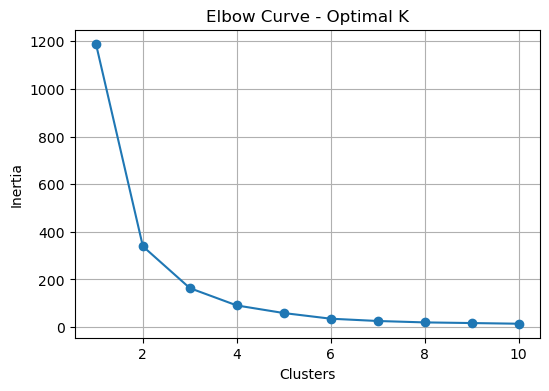

In [5]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Curve - Optimal K")
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()


In [6]:
kmeans = KMeans(n_clusters=6, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)
df.head()


c:\Users\sunba\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency,Cluster
0,1,25,45000,200,4.5,North,12,1
1,2,34,55000,350,7.0,South,18,5
2,3,45,65000,500,8.0,West,22,3
3,4,22,30000,150,3.0,East,10,4
4,5,29,47000,220,4.8,North,13,1


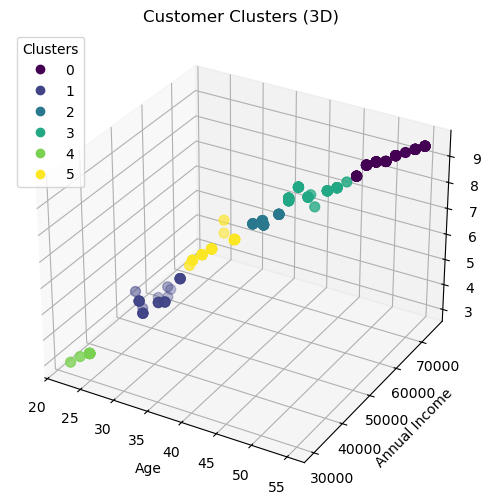

In [7]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df['age'], df['annual_income'], df['loyalty_score'],
                     c=df['Cluster'], s=50)

ax.set_xlabel("Age")
ax.set_ylabel("Annual Income")
ax.set_zlabel("Loyalty Score")
ax.set_title("Customer Clusters (3D)")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()


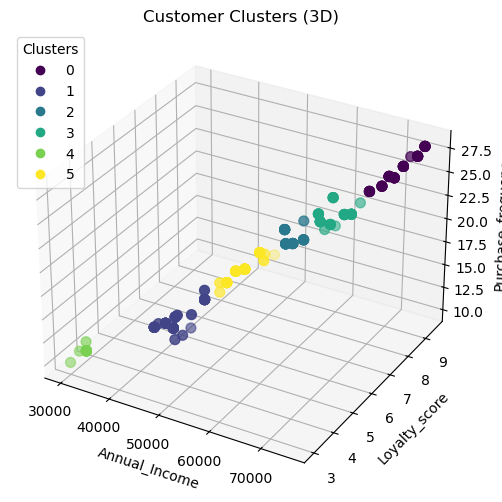

In [8]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df['annual_income'], df['loyalty_score'],df['purchase_frequency'],
                     c=df['Cluster'], s=50)

ax.set_xlabel("Annual_Income")
ax.set_ylabel("Loyalty_score")
ax.set_zlabel("Purchase_frequency")
ax.set_title("Customer Clusters (3D)")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()


In [9]:
cluster_summary = df.groupby('Cluster')[selected_features].mean()
cluster_summary


,age,annual_income,purchase_amount,loyalty_score,purchase_frequency
Cluster,,,,,
0,51.135593,71135.593220,602.711864,9.066102,25.508475
1,27.883721,45674.418605,253.488372,4.395349,14.441860
2,38.500000,58500.000000,435.000000,6.975000,20.312500
3,43.217391,63217.391304,493.913043,7.939130,21.826087
4,23.812500,31812.500000,168.125000,3.275000,11.000000
5,33.047619,52690.476190,369.285714,6.007143,18.000000


| Cluster | Profile Summary                                                                 | Behavioral Pattern                          | Marketing Strategy                                             |
| ------- | ------------------------------------------------------------------------------- | ------------------------------------------- | -------------------------------------------------------------- |
| **0**   | Older (51+), high income, highest spending, very loyal, frequent purchases      | Premium segment with strong brand loyalty   | Offer VIP memberships, exclusives, early product access        |
| **1**   | Young (20s), lower income, low spend, low loyalty                               | Price-sensitive casual shoppers             | Student discounts, affordable bundles, engagement campaigns    |
| **2**   | Mid-age (38+), good income, medium spend, good loyalty                          | Growing loyal shoppers                      | Upsell & cross-sell personalized recommendations               |
| **3**   | Mid-age (43+), higher income, fairly high spend & loyalty                       | Stable high-value customers                 | Targeted retention & reward programs                           |
| **4**   | Very young (early 20s), lowest income, lowest spend & frequency, lowest loyalty | New customers with shallow brand attachment | Awareness campaigns, social media marketing & gamified rewards |
| **5**   | Young adults (33+), moderate income, medium spending & loyalty                  | Potential repeat customers                  | Loyalty point boosters, event-based offers                     |


**Strategic Summary**

Clusters 0 & 3 are your high-value segments → prioritize retention

Cluster 2 & 5 show growth potential → increase loyalty through targeted offers

Cluster 1 & 4 are low-spend but young → long-term customer nurturing + promotional pricing

**Key Takeaways for Decision Makers ✅**

Age and income strongly influence purchasing power

Loyalty score correlates with purchase amount and frequency

Marketing segmentation should not treat customers uniformly
→ Each cluster has distinct revenue potential

**✅ Final Conclusion**

The clustering analysis successfully segmented customers into six distinct groups based on age, income, purchasing amount, loyalty score, and frequency of purchase. Visualizations including bar charts and radar plots helped uncover the behavioral patterns of each segment:

**Cluster 0**: Older, high-income, most loyal and highest spenders — Premium Loyal Segment

**Cluster 3**: Mid-aged with strong spending and loyalty — Growing Value Champions

**Cluster 2 & 5**: Moderate income and loyalty — Average Steady Buyers

**Cluster 1**: Younger, lower spend and loyalty — Price-Conscious Shoppers

**Cluster 4**: Youngest and lowest spend — Low Engagement / At-Risk Customers

These insights enable targeted marketing strategies, such as premium membership offers for high-value clusters, retention campaigns for moderate spenders, and entry-level incentives for low-engagement groups.

Overall, the clustering approach demonstrated clear, actionable personas that can improve personalization, loyalty, and business revenue if applied to real-world marketing decisions. Future improvements may include adding more demographic and behavioral features, testing different clustering algorithms (e.g., DBSCAN, Gaussian Mixture), and validating clusters using silhouette scoring for optimal group selection.